#### K-Means to Find Seniority of the Employees in a Company

In [173]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#### Data Preprocessing

In [174]:
dataset = pd.read_csv("../data/jobs.csv")
dataset.head()

,Experience,Salary
0,1.0,38400
1,1.1,39343
2,1.3,36205
3,1.5,37731
4,2.0,38525


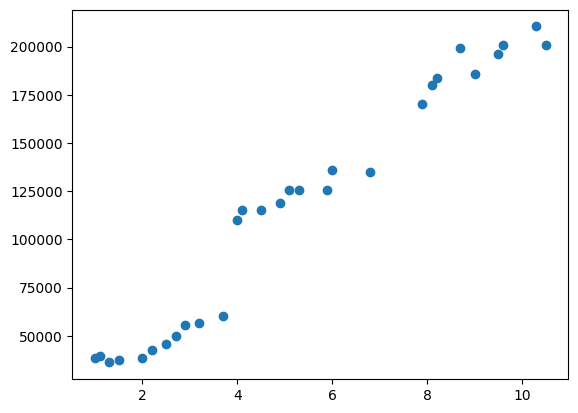

In [175]:
# Juniors, Seniors, and Most Seniors
plt.scatter(dataset["Experience"],dataset["Salary"])

In [176]:
Km = KMeans(n_clusters=3)

In [177]:
Km.fit(dataset[["Experience"]],dataset[["Salary"]])

c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=3)

In [178]:
postion = Km.predict(dataset[["Experience"]])

In [179]:
job_position = []
for p in postion:
    job_position.insert(0,p)

In [180]:
dataset["position"] = job_position

In [181]:
dataset.head()

,Experience,Salary,position
0,1.0,38400,0
1,1.1,39343,0
2,1.3,36205,0
3,1.5,37731,0
4,2.0,38525,0


In [182]:
def set_position_name(x):
    if(x == 0):
        return "Junior"
    elif(x == 1):
        return "Senior"
    else:
        return "Most Senior"

In [183]:
dataset["position_name"] = dataset["position"].apply(lambda x: set_position_name(x))

In [184]:
dataset.head()

,Experience,Salary,position,position_name
0,1.0,38400,0,Junior
1,1.1,39343,0,Junior
2,1.3,36205,0,Junior
3,1.5,37731,0,Junior
4,2.0,38525,0,Junior


In [185]:
df_junior = dataset[dataset["position"] == 0]
df_senior = dataset[dataset["position"] == 1]
df_m_senior = dataset[dataset["position"] == 2]

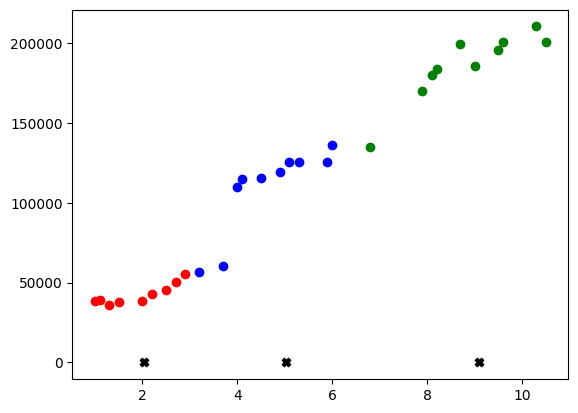

In [186]:
plt.scatter(df_junior["Experience"],df_junior["Salary"],c="red")
plt.scatter(df_senior["Experience"],df_senior["Salary"],c="green")
plt.scatter(df_m_senior["Experience"],df_m_senior["Salary"],c="blue")
plt.scatter(Km.cluster_centers_[:],Km.cluster_centers_[:],c="black",marker="X")

#### Finding Elbow Point

In [200]:
# Find the elbow point
k_range = range(1,5)
sse = []
for k in k_range:
    km = KMeans(n_clusters=k)
    km.fit(dataset[["Experience","Salary"]])
    sse.append(Km.inertia_)

sse

c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\si

[21.693888888888893,
 21.693888888888893,
 21.693888888888893,
 21.693888888888893]